In [ ]:
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import KFold
from PIL import Image
from tqdm import tqdm
import itertools
import random
import torchvision
import torch
import cv2
import json
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,classification_report
import numpy as np
from sklearn.metrics import accuracy_score
import seaborn as sns
from torchsummary import summary
import torch


# **Experimento I**

## **Clase Neuronal I**

In [ ]:
from math import isnan
class Neuronal(torch.nn.Module):

    def __init__(self, num_filters):
        super(Neuronal, self).__init__()

        # Conv
        self.conv1 = torch.nn.Conv2d(1, num_filters[0],
                                     kernel_size=3, padding=1)
        self.pool1 = torch.nn.MaxPool2d(kernel_size=2, stride=2)

        #
        self.conv2 = torch.nn.Conv2d(num_filters[0], num_filters[1],
                                     kernel_size=3, padding=1)
        self.pool2 = torch.nn.MaxPool2d(kernel_size=2, stride=2)

        #
        self.conv3 = torch.nn.Conv2d(num_filters[1], num_filters[2],
                                    kernel_size=3, padding=1)
        self.pool3 = torch.nn.MaxPool2d(kernel_size=2, stride=2)


        self.dropout = torch.nn.Dropout(0.2)

        # Eliminar esta capa del proceso
        self.conv4 = torch.nn.Conv2d(num_filters[2], num_filters[3],
                                     kernel_size=3, padding=1)
        self.pool4 = torch.nn.MaxPool2d(kernel_size=2, stride=2)

        # Flatten
        self.flatten = torch.nn.Flatten()

        # Full Connect -->> revisar el contenido de la capa full conect
        self.fc1 = torch.nn.Linear(64 * 81 * 80, 512) # Corrected input features: 64 * 81 * 80 = 414720
        self.fc2 = torch.nn.Linear(512,512)
        self.fc3 = torch.nn.Linear(512, 2) # dos capas de salida del proceso
        #
        self.lgSoftMax = torch.nn.LogSoftmax(dim=1)


    def forward(self, x):
      # Interconexion niveles arquitectura de la red
      x = self.pool1(torch.nn.ReLU()(self.conv1(x)))
      x = self.pool2(torch.nn.ReLU()(self.conv2(x)))
      x = self.pool3(torch.nn.ReLU()(self.conv3(x)))
      #x = self.pool4(torch.nn.ReLU()(self.conv4(x)))

      # Aplanamiento de datos
      x = self.flatten(x) # dimension de la última capa
      # Capas densas del proceso
      x = self.fc1(x)
      x = self.dropout(x) #--> metodo de regularización
      x = self.fc2(x)
      x = self.fc3(x)
      #
      x = self.lgSoftMax(x)
      return x

In [ ]:
# Descomentar para ver estructura de la red #
#NW = Neuronal(num_filters=[16,32,64,128])
#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#NW.to(device)
#summary(NW, (1, 650, 644));

## **Clase ImageDataset**

In [ ]:
class ImageDataset(torch.utils.data.Dataset):
    def __init__(self, paths, labels):
        self.images = paths
        self.labels = labels

    def __len__(self):
      return len(self.images)

    def __getitem__(self, idx):
      path = self.images[idx]
      image = Image.open(self.images[idx]).convert('L') # Convert to grayscale
      transform = torchvision.transforms.ToTensor()
      image_tensor = transform(image)
      label = self.labels[idx]
      return image_tensor, torch.tensor(label, dtype=torch.long), path

In [ ]:
class EarlyStopping:
    def __init__(self, tolerance=5, min_delta=0):

        self.tolerance = tolerance
        self.min_delta = min_delta
        self.counter = 0
        self.early_stop = False

    def __call__(self, train_loss, validation_loss):
        if (validation_loss - train_loss) > self.min_delta:
            self.counter +=1
            if self.counter >= self.tolerance:
                self.early_stop = True

## **Clase DetectHandPD (Main)**

In [ ]:
class DetectHandPD:
  global path_base
  path_base = '/content/drive/MyDrive/'

  def __init__(self, t_type ,percent, n_epochs):
    self.seed_step(42)
    self.n_epochs = n_epochs
    self.t_type = t_type
    self.path_model = f'{path_base}models/{t_type}/'
    self.path_H = f"{path_base}{t_type}Control_out_resize/"
    self.path_S = f"{path_base}{t_type}Patients_out_resize/"
    self.path_schema = f"{path_base}{t_type}_id_train_test_{percent}_percent.json"
    #
    self.ids_process = self.load_ids_data(self.path_schema)
    self.trainDataset = self.createDataset(self.ids_process['id_train'])
    self.testDataset = self.createDataset(self.ids_process['id_test'])
    self.trainloader = torch.utils.data.DataLoader(self.trainDataset,
                                                   shuffle=True)
    self.testloader = torch.utils.data.DataLoader(self.testDataset,
                                                   shuffle=True)
    self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    self.model = Neuronal(num_filters=[16,32,64,128]) #Neuronal(num_filters=[32,64,128,192])
    self.model.to(self.device) # Move model to device right after creation
    self.f_cost = torch.nn.CrossEntropyLoss()
    self.optimizer = torch.optim.SGD(self.model.parameters(),
                                      lr=0.001, momentum=0.9)
    #0.0001
    self.earlyStopping = EarlyStopping(tolerance=5, min_delta=0.001)
    self.kfold = KFold(n_splits=2, shuffle=True, random_state=42)

  def reset_weights(self, m):
    '''
      Try resetting model weights to avoid
      weight leakage.
    '''
    for layer in m.children():
      if hasattr(layer, 'reset_parameters'):
        #print(f'Reset trainable parameters of layer = {layer}')
        layer.reset_parameters()

  def load_ids_data(self, path):
    """
    @path : ruta del fichero json
    @return : diccionario con los datos del fichero
    """
    with open(path, "r") as f:
      data = json.load(f)
    return data

  def seed_step(self, seed_value):
    """
    @seed_value : valor de la semilla a utilizar
    @return : None
    """
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)

  def save_model(self,epoch):
    """
    @path : ruta donde se almacena el modelo
    @return : None
    """
    torch.save(self.model.state_dict() , f"{self.path_model}{self.t_type}_{epoch}.pth")

  def load_model(self, path_model):
    """
    @path : ruta del modelo a cargar
    @return : None
    """
    state_dict = torch.load(path_model, map_location=self.device)
    self.model.load_state_dict(state_dict)
    self.model.to(self.device) # Add this line to move the model to the correct device
    self.model.eval()

  def search_data(self, ids, status):
    """
    @ids : lista con los ids de los pacientes
    @status : 0 -> Healthy, 1 -> Sick
    @return : lista de la ruta de las imagenes de los pacientes
    """
    list_data = []
    path = self.path_H if status == 0 else self.path_S
    for i in glob.glob(path+"*_TH.jpg"):
      user = i.split("/")[-1].split("-")[0]
      if user in ids:
        list_data.append(i)
    #
    labels = list(itertools.repeat(status, len(list_data)))
    #
    return list_data, labels


  def createDataset(self, ids):
    """
    @ids : json con los ids a utilizar para la red
    @return : objeto de tipo ImageDataset
    """
    data_h, labels_h = self.search_data(ids['healthy'], 0)
    data_s, labels_s = self.search_data(ids['sick'], 1)
    data_all = data_h + data_s
    labels_all = labels_h + labels_s
    #
    return ImageDataset(data_all, labels_all)


  def train_step(self):
    """
    @return : None
    """
    self.model.to(self.device)
    acc_train = []
    loss_data = []
    # incluir el valor de la funcion de coste
    for epoch in range(self.n_epochs):
      self.model.train()
      running_loss = 0.0
      trainCorrect = 0
      for batch_index,  (inputs, labels, path) in enumerate(tqdm(self.trainloader)):
        if self.device.type == 'cuda':
          inputs, labels = inputs.to(self.device), labels.to(self.device)
        # Zero the parameter gradients
        self.optimizer.zero_grad()
        # Forward pass
        outputs = self.model(inputs)
        # Compute the loss
        loss = self.f_cost(outputs, labels)
        #loss_data.append(loss.item())
        # Backward pass and optimize
        loss.backward()
        self.optimizer.step()
        # Print statistics
        running_loss += loss.item()
        #######
      loss_data.append(running_loss/len(self.trainloader))

      # Parametros de accuracy
      with torch.no_grad():
        #  computing training accuracy
        train_accuracy = self.accuracy(self.model, self.trainloader)
        acc_train.append(train_accuracy)
        #print(f'deriving training accuracy is {train_accuracy}')

      if epoch  in [5,10,15,20,30,40]:
        self.save_model(epoch)
        print(f'[Epoch {epoch}, Batch {batch_index + 1}] \
            avg_loss: {round(running_loss/len(self.trainloader), 4)} \
            accuracy_train:{train_accuracy}')

      # early stopping

    #valores medios totales epocas y todos los datos
    avg_train_loss = np.array(loss_data).mean()
    avg_train_accuracy = np.array(acc_train).mean()
    #
    print(f'avg_train_loss: {round(avg_train_loss, 4)},\
          avg_train_accuracy: {round(avg_train_accuracy, 4)}')
    #
    return loss_data, acc_train


  def accuracy(self, network, dataloader):
    '''
    @network : red neuronal
    @dataloader : dataloader de entrenamiento
    '''
    network.eval()
    total_correct = 0
    total_instances = 0
    for images, labels , path in tqdm(dataloader):
      images, labels = images.to(self.device), labels.to(self.device)
      predictions = torch.argmax(network(images), dim=1)
      correct_predictions = sum(predictions==labels).item()
      total_correct+=correct_predictions
      total_instances+=len(images)
    #
    return round(total_correct/total_instances, 3)



  def train_step_kfold(self):
    """
    @return : None
    """
    for fold, (train_ids, vals_ids) in enumerate(self.kfold.split(self.trainDataset)):
      print(f'FOLD {fold}')
      print('--------------------------------')
      # Sample elements randomly from a given list of ids, no replacement.
      train_subsampler = torch.utils.data.SubsetRandomSampler(train_ids)
      valide_subsampler = torch.utils.data.SubsetRandomSampler(vals_ids)
      # Define data loaders for training and testing data in this fold
      trainloader = torch.utils.data.DataLoader(self.trainDataset,
                                                sampler=train_subsampler)
      valideloader = torch.utils.data.DataLoader(self.trainDataset,
                                                 sampler=valide_subsampler)

      self.model.to(self.device)
      self.model.apply(self.reset_weights)
      self.optimizer = torch.optim.SGD(self.model.parameters(),
                                      lr=0.001, momentum=0.9)
      acc_train = []
      loss_data_folk_train = []
      loss_data_folk_val = []

      for epoch in range(self.n_epochs):
        self.model.train()
        trainCorrect = 0
        running_loss = 0.0
        for batch_index,  (inputs, labels, paths) in enumerate(tqdm(trainloader)):
          if self.device.type == 'cuda': # Use self.device here
            inputs, labels = inputs.to(self.device), labels.to(self.device)# Use self.device here
          # Zero the parameter gradients
          self.optimizer.zero_grad()
          # Forward pass
          outputs = self.model(inputs)
          # Compute the loss
          loss = self.f_cost(outputs, labels)
          #loss_data.append(loss.item())
          # Backward pass and optimize
          loss.backward()
          self.optimizer.step()
          # Print statistics
          running_loss += loss.item()
          #######

        loss_data_folk_train.append(running_loss/len(trainloader))

        # Parametros de accuracy
        with torch.no_grad():
          #  computing training accuracy
          df_results, val_accuracy, val_losses_mean = self.test_step(valideloader)
          acc_train.append(val_accuracy)
          loss_data_folk_val.append(val_losses_mean)
          #print(f'deriving training accuracy is {train_accuracy}')

        print(f'[Epoch {epoch + 1}, Batch {batch_index + 1}] \
            avg_loss: {round(running_loss/len(trainloader), 4)} \
            accuracy_train:{val_accuracy}')

      #valores medios totales epocas y todos los datos
      avg_train_loss = np.array(loss_data_folk_train).mean()
      avg_train_accuracy = np.array(acc_train).mean()
      #
      print(f'fold_avg_train_loss: {round(avg_train_loss, 4)},\
          fold_avg_train_accuracy: {round(avg_train_accuracy, 4)}')
      #
      #torch.save(self.model.state_dict , self.path_model+'kfold_'+str(fold)+'.pth')
      #
    return loss_data_folk_train, loss_data_folk_val #loss_data, acc_train


  def test_step(self, testloader):
    """
    @return : DataFrame of predictions and true labels, and validation accuracy
    """
    print('validating...')
    val_losses = []
    all_predicted_classes = []
    all_true_labels = []
    all_paths = []

    self.model.eval()
    with torch.no_grad():
      for images, labels, path in tqdm(testloader):
        images, labels = images.to(self.device), labels.to(self.device)
        outputs = self.model(images)
        val_loss = self.f_cost(outputs, labels)
        val_losses.append(val_loss.item())

        _, predicted = torch.max(outputs.data, 1)
        all_predicted_classes.extend(predicted.cpu().numpy())
        all_true_labels.extend(labels.cpu().numpy())
        all_paths.extend(path)

      #val_accuracy = self.accuracy(self.model, self.testloader)


    val_losses_mean = np.array(val_losses).mean()
    val_accuracy = accuracy_score(y_true=all_true_labels,
                              y_pred=all_predicted_classes)

    print(f'validation_loss: {round(val_losses_mean, 4)} '+
            f'validation_accuracy: {val_accuracy}\n')

    df_results = pd.DataFrame({
        'path': all_paths,
        'true_label': all_true_labels,
        'predicted_label': all_predicted_classes
    })

    return df_results, val_accuracy, val_losses_mean

  def run(self, exec_mode, sub_t_type,):
    print(f"<Execute mode:{exec_mode}> <Type base:{self.t_type}> <Sub-Type:{sub_t_type}>")

    loss_data = []
    acc_train = []
    df_data_test = pd.DataFrame() # Initialize as an empty DataFrame

    if exec_mode == 'train':
      loss_data, acc_train = self.train_step()
      self.save_model(self.n_epochs)

    if exec_mode == 'test':
      self.path_model  = f"{self.path_model}{self.t_type}_{self.n_epochs}.pth"
      path = self.path_model if sub_t_type == self.t_type else\
            self.path_model.replace(self.t_type,sub_t_type)
      print(path)
      print(self.path_H)
      self.load_model(path)
      df_data_test, val_accuracy, val_losses_mean = self.test_step(self.testloader) # Test step now returns DataFrame and accuracy

    return loss_data, acc_train, df_data_test

## **Entrenamiento de la red (Main)**

Se lanza el entrenamiento de la red para los grupos Spiral y Meander. En la ejecución se indica el número de epoches totales.

In [ ]:
list_exe = ['Spiral', 'Meander']
list_data_exe = []
for t_type in list_exe:
  detect = DetectHandPD(t_type, 60, 50)
  loss_data, acc_train, df_data = detect.run('train',t_type)
  list_data_exe.append((loss_data, acc_train))

<Execute mode:train> <Type base:Spiral> <Sub-Type:Spiral>


100%|██████████| 80/80 [00:00<00:00, 85.71it/s]


[Epoch 5, Batch 80]             avg_loss: 0.6943             accuracy_train:0.5


100%|██████████| 80/80 [00:01<00:00, 65.79it/s]


[Epoch 10, Batch 80]             avg_loss: 0.4911             accuracy_train:0.688


...

[Epoch 30, Batch 80]             avg_loss: 0.4571             accuracy_train:0.912


100%|██████████| 80/80 [00:01<00:00, 74.02it/s]


[Epoch 40, Batch 80]             avg_loss: 0.0004             accuracy_train:1.0


100%|██████████| 80/80 [00:01<00:00, 78.07it/s]


avg_train_loss: 0.4188,          avg_train_accuracy: 0.7732


Para cada ejecución se gráfica los resultados

In [ ]:
list_data_exe0_0 = list_data_exe[0]
list_data_exe0_1 = list_data_exe[1]

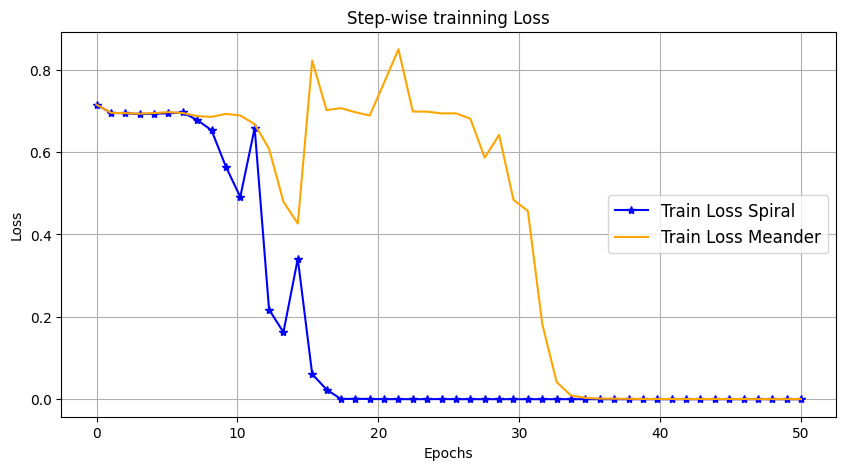

In [ ]:
step = np.linspace(0,50, len(list_data_exe0_0[0]))
fig, ax = plt.subplots(figsize=(10,5))
plt.plot(step, np.array(list_data_exe0_0[0]), label='Train Loss Spiral',
         color='blue', marker='*')
plt.plot(step, np.array(list_data_exe0_1[0]), label='Train Loss Meander',
         color='orange')
plt.title("Step-wise trainning Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(loc='center right', fontsize=12)
plt.grid(True)
plt.show()

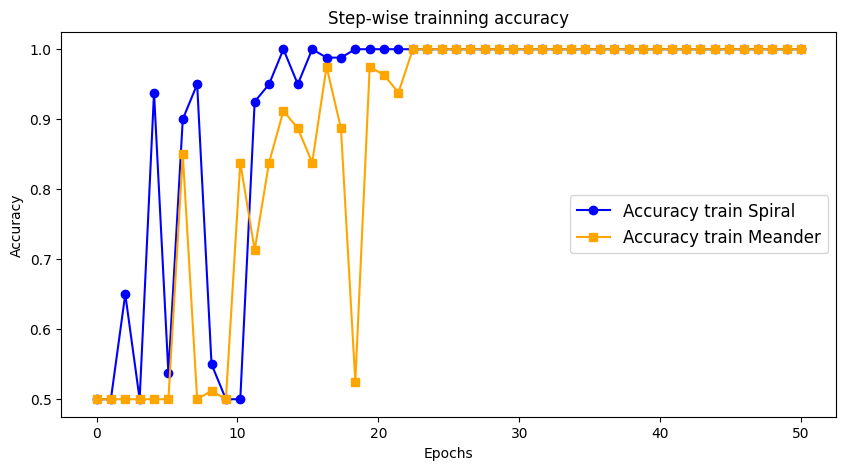

In [ ]:
step = np.linspace(0,50, len(list_data_exe0_0[1]))
fig, ax = plt.subplots(figsize=(10,5))
plt.plot(step, np.array(list_data_exe0_0[1]), label='Accuracy train Spiral',
         color='blue', marker='o')
plt.plot(step, np.array(list_data_exe0_1[1]), label='Accuracy train Meander',
         color='orange', marker='s')
plt.title("Step-wise trainning accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(loc='center right', fontsize=12)
plt.grid(visible=True, which='major', axis='both',
         color="#FFFFFF",linewidth=1)
plt.show()

## **Test de la Red**

Se pasa a obtener las métricas en la etapa de Test para cada una los tipos de pruebas realizadas por el paciente.

In [ ]:
list_exe = ['Spiral','Meander']
for i in [5,10,15,20,30,40,50]:
  print(f"Epochs: {i}")
  for t_type in list_exe:
    detect = DetectHandPD(t_type, 60, i)
    loss_data, acc_train, df_data_test = detect.run('test',t_type)

5
<Execute mode:test> <Type base:Spiral> <Sub-Type:Spiral>
validating...


100%|██████████| 288/288 [01:22<00:00,  3.50it/s]


validation_loss: 0.725 validation_accuracy: 0.1111111111111111

<Execute mode:test> <Type base:Meander> <Sub-Type:Meander>
validating...


100%|██████████| 288/288 [01:29<00:00,  3.22it/s]


validation_loss: 0.7104 validation_accuracy: 0.1111111111111111

10
<Execute mode:test> <Type base:Spiral> <Sub-Type:Spiral>
validating...


...

validation_loss: 1.6315 validation_accuracy: 0.6076388888888888

50
<Execute mode:test> <Type base:Spiral> <Sub-Type:Spiral>
validating...


100%|██████████| 288/288 [01:18<00:00,  3.67it/s]


validation_loss: 1.8099 validation_accuracy: 0.71875

<Execute mode:test> <Type base:Meander> <Sub-Type:Meander>
validating...


100%|██████████| 288/288 [01:18<00:00,  3.68it/s]

validation_loss: 1.6658 validation_accuracy: 0.6215277777777778



Una vez, analizados los resultados nos quedamos los elementos más representativos para cada conjunto de datos.

## **Spiral test**

In [ ]:
detect = DetectHandPD('Spiral', 60, 15)
loss_data_s, acc_train_s, df_data_test_s = detect.run('test','Spiral')

<Execute mode:test> <Type base:Spiral> <Sub-Type:Spiral>
/content/drive/MyDrive/models/Spiral/Spiral_15.pth
/content/drive/MyDrive/SpiralControl_out_resize/
validating...


100%|██████████| 288/288 [00:03<00:00, 74.37it/s]

validation_loss: 0.608 validation_accuracy: 0.7743055555555556



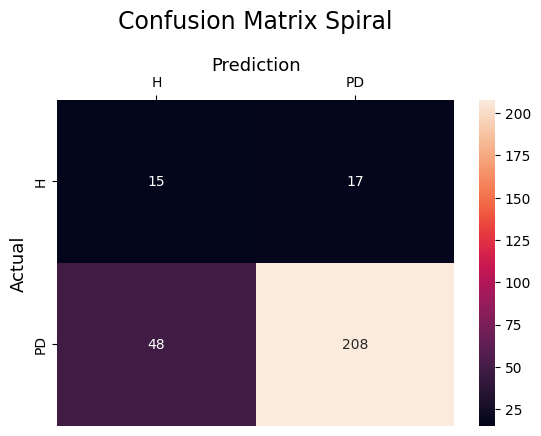

In [ ]:
cm = confusion_matrix(df_data_test_s['true_label'],
                      df_data_test_s['predicted_label'])

sns.heatmap(cm,
            annot=True,
            fmt='g',
            xticklabels=['H','PD'],
            yticklabels=['H','PD'])
plt.ylabel('Actual', fontsize=13)
plt.title('Confusion Matrix Spiral', fontsize=17, pad=20)
plt.gca().xaxis.set_label_position('top')
plt.xlabel('Prediction', fontsize=13)
plt.gca().xaxis.tick_top()

plt.gca().figure.subplots_adjust(bottom=0.2)
plt.savefig('c_matrix_spiral.png', dpi=300)
plt.show()

In [ ]:
print(classification_report(df_data_test_s['true_label'], df_data_test_s['predicted_label']))

              precision    recall  f1-score   support

           0       0.24      0.47      0.32        32
           1       0.92      0.81      0.86       256

    accuracy                           0.77       288
   macro avg       0.58      0.64      0.59       288
weighted avg       0.85      0.77      0.80       288



Para obtener alguna de las muestras que se han acertado o fallado se obtienen alguno de los datos para **espirales**

In [ ]:
df_data_test_fail_s = df_data_test_s[df_data_test_s['true_label'] != df_data_test_s['predicted_label']]
df_data_test_ok_s = df_data_test_s[df_data_test_s['true_label'] == df_data_test_s['predicted_label']]

/content/drive/MyDrive/SpiralPatients_out_resize/0240-1_TH.jpg
/content/drive/MyDrive/SpiralPatients_out_resize/0157-1_TH.jpg
/content/drive/MyDrive/SpiralPatients_out_resize/0038-3_TH.jpg
/content/drive/MyDrive/SpiralPatients_out_resize/0010-3_TH.jpg
/content/drive/MyDrive/SpiralPatients_out_resize/0153-2_TH.jpg
/content/drive/MyDrive/SpiralPatients_out_resize/0234-4_TH.jpg
/content/drive/MyDrive/SpiralPatients_out_resize/0031-1_TH.jpg
/content/drive/MyDrive/SpiralPatients_out_resize/0274-3_TH.jpg
/content/drive/MyDrive/SpiralControl_out_resize/0116-3_TH.jpg


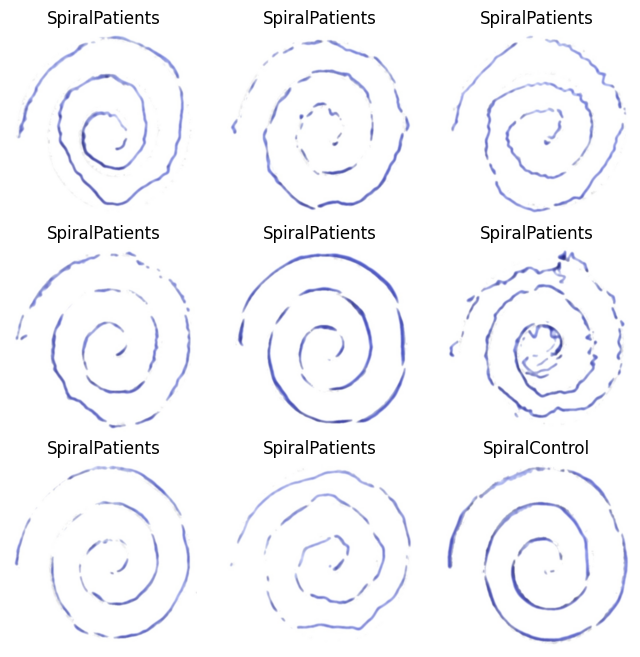

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1 import ImageGrid

fig = plt.figure(figsize=(8, 8))
# Crea un grid de 2 filas y 2 columnas
grid = ImageGrid(fig, 111, nrows_ncols=(3, 3), axes_pad=0.3)

for ax, im_path in zip(grid, df_data_test_ok_s['path']):
    print(im_path)
    true_label = im_path.split("/")[-2].split("_")[0]
    ax.imshow(mpimg.imread(im_path))
    ax.set_title(true_label)
    ax.axis('off') # Oculta los ejes

plt.savefig('grid_spiral_ok.png', dpi=300)
plt.show()

/content/drive/MyDrive/SpiralPatients_out_resize/0165-4_TH.jpg
/content/drive/MyDrive/SpiralPatients_out_resize/0143-1_TH.jpg
/content/drive/MyDrive/SpiralControl_out_resize/0289-4_TH.jpg
/content/drive/MyDrive/SpiralPatients_out_resize/0024-3_TH.jpg
/content/drive/MyDrive/SpiralPatients_out_resize/0202-1_TH.jpg
/content/drive/MyDrive/SpiralPatients_out_resize/0009-2_TH.jpg
/content/drive/MyDrive/SpiralPatients_out_resize/0031-4_TH.jpg
/content/drive/MyDrive/SpiralPatients_out_resize/0143-4_TH.jpg
/content/drive/MyDrive/SpiralPatients_out_resize/0280-2_TH.jpg


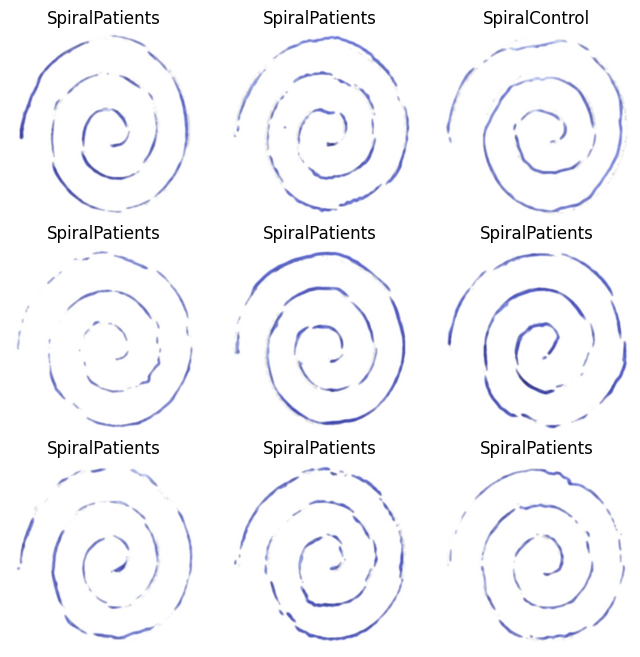

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1 import ImageGrid

fig = plt.figure(figsize=(8, 8))
# Crea un grid de 2 filas y 2 columnas
grid = ImageGrid(fig, 111, nrows_ncols=(3, 3), axes_pad=0.3)

for ax, im_path in zip(grid, df_data_test_fail_s['path']):
    true_label = im_path.split("/")[-2].split("_")[0]
    print(im_path)
    ax.imshow(mpimg.imread(im_path))
    ax.set_title(true_label)
    ax.axis('off') # Oculta los ejes

plt.savefig('grid_spiral_ko.png', dpi=300)
plt.show()

## **Meander test**

In [ ]:
detect = DetectHandPD('Meander', 60, 30)
loss_data_m, acc_train_m, df_data_test_m = detect.run('test','Meander')

<Execute mode:test> <Type base:Meander> <Sub-Type:Meander>
/content/drive/MyDrive/models/Meander/Meander_30.pth
/content/drive/MyDrive/MeanderControl_out_resize/
validating...


100%|██████████| 288/288 [00:04<00:00, 67.16it/s]

validation_loss: 0.4312 validation_accuracy: 0.8472222222222222



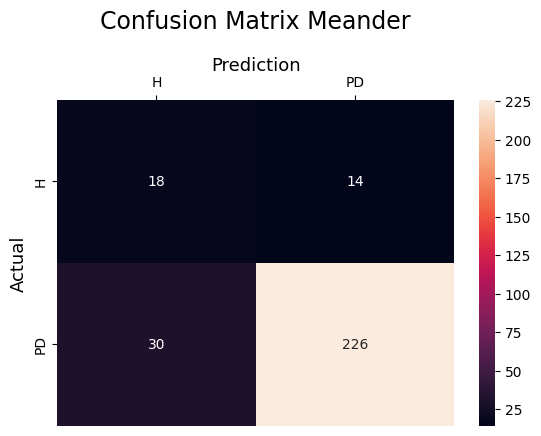

In [ ]:
cm = confusion_matrix(df_data_test_m['true_label'],
                      df_data_test_m['predicted_label'])

sns.heatmap(cm,
            annot=True,
            fmt='g',
            xticklabels=['H','PD'],
            yticklabels=['H','PD'])
plt.ylabel('Actual', fontsize=13)
plt.title('Confusion Matrix Meander', fontsize=17, pad=20)
plt.gca().xaxis.set_label_position('top')
plt.xlabel('Prediction', fontsize=13)
plt.gca().xaxis.tick_top()

plt.gca().figure.subplots_adjust(bottom=0.2)
plt.savefig('c_matrix_meander.png', dpi=300)
plt.show()

In [ ]:
print(classification_report(df_data_test_m['true_label'], df_data_test_m['predicted_label']))

              precision    recall  f1-score   support

           0       0.38      0.56      0.45        32
           1       0.94      0.88      0.91       256

    accuracy                           0.85       288
   macro avg       0.66      0.72      0.68       288
weighted avg       0.88      0.85      0.86       288



Para obtener alguna de las muestras que se han acertado o fallado se obtienen alguno de los datos para **meanders**

In [ ]:
df_data_test_fail_m = df_data_test_m[df_data_test_s['true_label'] != df_data_test_m['predicted_label']]
df_data_test_ok_m = df_data_test_m[df_data_test_m['true_label'] == df_data_test_m['predicted_label']]

/content/drive/MyDrive/MeanderPatients_out_resize/0149-6_TH.jpg
/content/drive/MyDrive/MeanderPatients_out_resize/0242-8_TH.jpg
/content/drive/MyDrive/MeanderPatients_out_resize/0143-5_TH.jpg
/content/drive/MyDrive/MeanderPatients_out_resize/0031-5_TH.jpg
/content/drive/MyDrive/MeanderPatients_out_resize/0004-5_TH.jpg
/content/drive/MyDrive/MeanderPatients_out_resize/0138-5_TH.jpg
/content/drive/MyDrive/MeanderPatients_out_resize/0240-5_TH.jpg
/content/drive/MyDrive/MeanderPatients_out_resize/0148-5_TH.jpg
/content/drive/MyDrive/MeanderPatients_out_resize/0280-6_TH.jpg


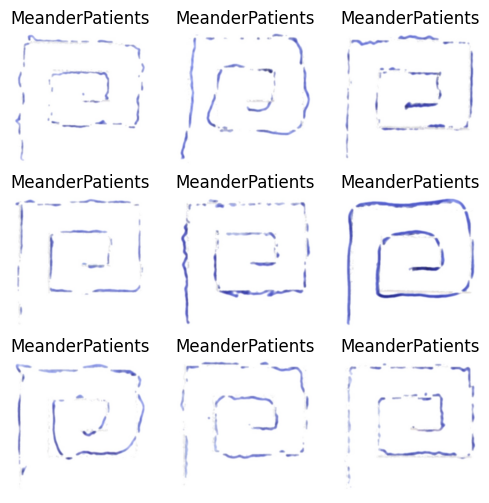

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1 import ImageGrid

fig = plt.figure(figsize=(6, 6))
# Crea un grid de 2 filas y 2 columnas
grid = ImageGrid(fig, 111, nrows_ncols=(3, 3), axes_pad=0.3)

for ax, im_path in zip(grid, df_data_test_ok_m['path']):
    true_label = im_path.split("/")[-2].split("_")[0]
    print(im_path)
    ax.imshow(mpimg.imread(im_path))
    ax.set_title(true_label)
    ax.axis('off') # Oculta los ejes

plt.savefig('grid_meander_ok.png', dpi=300)
plt.show()

/content/drive/MyDrive/MeanderPatients_out_resize/0037-5_TH.jpg
/content/drive/MyDrive/MeanderControl_out_resize/0098-6_TH.jpg
/content/drive/MyDrive/MeanderPatients_out_resize/0214-5_TH.jpg
/content/drive/MyDrive/MeanderPatients_out_resize/0009-7_TH.jpg
/content/drive/MyDrive/MeanderControl_out_resize/0098-8_TH.jpg
/content/drive/MyDrive/MeanderControl_out_resize/0127-5_TH.jpg
/content/drive/MyDrive/MeanderControl_out_resize/0104-8_TH.jpg
/content/drive/MyDrive/MeanderPatients_out_resize/0268-5_TH.jpg
/content/drive/MyDrive/MeanderPatients_out_resize/0213-6_TH.jpg


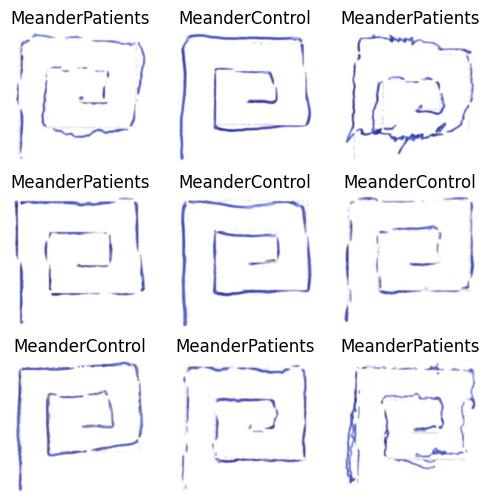

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1 import ImageGrid

fig = plt.figure(figsize=(6, 6))
# Crea un grid de 2 filas y 2 columnas
grid = ImageGrid(fig, 111, nrows_ncols=(3, 3), axes_pad=0.3)

for ax, im_path in zip(grid, df_data_test_fail_m['path']):
    true_label = im_path.split("/")[-2].split("_")[0]
    print(im_path)
    ax.imshow(mpimg.imread(im_path))
    ax.set_title(true_label)
    ax.axis('off') # Oculta los ejes

plt.savefig('grid_meander_ko.png', dpi=300)
plt.show()

# **Experimento II**

Las imágenes completas de la etapa de Test de cada una de las pruebas (espirales y meanders) se prueban con el modelo contrario. Es decir, el modelo entrenado con espirales se testea con *meanders* y viceversa.

In [ ]:
list_exe = ['Spiral','Meander']
for t_type in ['Spiral','Meander']:
  for i in [5,10,15,20,30,40,50]:
    print(f"Epochs: {i}")
    detect = DetectHandPD(t_type, 60, i)
    sub_t_type = 'Meander' if t_type == "Spiral" else "Spiral"
    loss_data, acc_train, df_data_test = detect.run('test', sub_t_type)

Epochs: 5
<Execute mode:test> <Type base:Spiral> <Sub-Type:Meander>
/content/drive/MyDrive/models/Meander/Meander_5.pth
validating...


100%|██████████| 288/288 [00:37<00:00,  7.67it/s]


validation_loss: 0.708 validation_accuracy: 0.1111111111111111

Epochs: 10
<Execute mode:test> <Type base:Spiral> <Sub-Type:Meander>
/content/drive/MyDrive/models/Meander/Meander_10.pth
validating...


100%|██████████| 288/288 [00:05<00:00, 49.70it/s]


validation_loss: 0.6773 validation_accuracy: 0.8888888888888888

Epochs: 15
<Execute mode:test> <Type base:Spiral> <Sub-Type:Meander>
/content/drive/MyDrive/models/Meander/Meander_15.pth
validating...


...

validation_loss: 0.8822 validation_accuracy: 0.7395833333333334

Epochs: 40
<Execute mode:test> <Type base:Meander> <Sub-Type:Spiral>
/content/drive/MyDrive/models/Spiral/Spiral_40.pth
validating...


100%|██████████| 288/288 [00:04<00:00, 68.11it/s]


validation_loss: 0.9297 validation_accuracy: 0.7395833333333334

Epochs: 50
<Execute mode:test> <Type base:Meander> <Sub-Type:Spiral>
/content/drive/MyDrive/models/Spiral/Spiral_50.pth
validating...


100%|██████████| 288/288 [00:03<00:00, 72.23it/s]

validation_loss: 0.9496 validation_accuracy: 0.7395833333333334



## **Modelo Espiral**

In [ ]:
t_type = 'Spiral'
detect = DetectHandPD(t_type, 60, 30)
sub_t_type = 'Meander' if t_type == "Spiral" else "Spiral"
loss_data_s_opos, acc_train_s_opos, df_data_test_s_opos = detect.run('test', sub_t_type)

<Execute mode:test> <Type base:Spiral> <Sub-Type:Meander>
/content/drive/MyDrive/models/Meander/Meander_30.pth
/content/drive/MyDrive/SpiralControl_out_resize/
validating...


100%|██████████| 288/288 [00:03<00:00, 75.40it/s]

validation_loss: 0.4395 validation_accuracy: 0.8506944444444444



In [ ]:
#df_data_test_s_opos

,path,true_label,predicted_label
0,/content/drive/MyDrive/MeanderPatients_out_res...,1,1
1,/content/drive/MyDrive/MeanderPatients_out_res...,1,1
2,/content/drive/MyDrive/MeanderPatients_out_res...,1,1
3,/content/drive/MyDrive/MeanderPatients_out_res...,1,1
4,/content/drive/MyDrive/MeanderPatients_out_res...,1,1
...,...,...,...
283,/content/drive/MyDrive/MeanderPatients_out_res...,1,1
284,/content/drive/MyDrive/MeanderPatients_out_res...,1,0
285,/content/drive/MyDrive/MeanderPatients_out_res...,1,0
286,/content/drive/MyDrive/MeanderPatients_out_res...,1,1


In [ ]:
df_data_test_fail_model_m = df_data_test_s_opos[df_data_test_s_opos['true_label'] != df_data_test_s_opos['predicted_label']]
df_data_test_ok_model_m = df_data_test_s_opos[df_data_test_s_opos['true_label'] == df_data_test_s_opos['predicted_label']]

/content/drive/MyDrive/SpiralPatients_out_resize/0165-4_TH.jpg
/content/drive/MyDrive/SpiralPatients_out_resize/0240-1_TH.jpg
/content/drive/MyDrive/SpiralPatients_out_resize/0157-1_TH.jpg
/content/drive/MyDrive/SpiralPatients_out_resize/0038-3_TH.jpg
/content/drive/MyDrive/SpiralPatients_out_resize/0010-3_TH.jpg
/content/drive/MyDrive/SpiralPatients_out_resize/0234-4_TH.jpg
/content/drive/MyDrive/SpiralPatients_out_resize/0143-1_TH.jpg
/content/drive/MyDrive/SpiralPatients_out_resize/0031-1_TH.jpg
/content/drive/MyDrive/SpiralPatients_out_resize/0274-3_TH.jpg


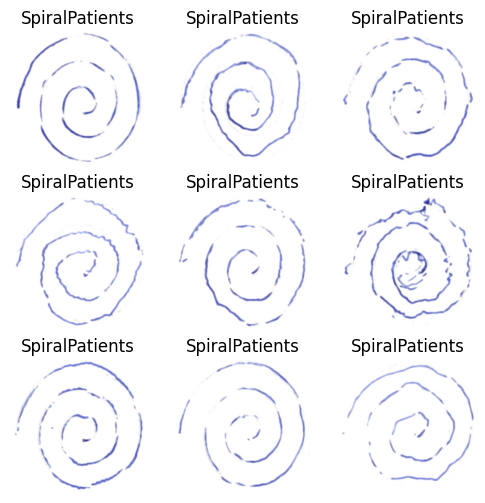

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1 import ImageGrid

fig = plt.figure(figsize=(6, 6))
# Crea un grid de 2 filas y 2 columnas
grid = ImageGrid(fig, 111, nrows_ncols=(3, 3), axes_pad=0.3)

for ax, im_path in zip(grid, df_data_test_ok_model_m['path']):
    true_label = im_path.split("/")[-2].split("_")[0]
    print(im_path)
    ax.imshow(mpimg.imread(im_path))
    ax.set_title(true_label)
    ax.axis('off') # Oculta los ejes

plt.savefig('grid_meander_ok.png', dpi=300)
plt.show()

/content/drive/MyDrive/SpiralPatients_out_resize/0153-2_TH.jpg
/content/drive/MyDrive/SpiralControl_out_resize/0289-4_TH.jpg
/content/drive/MyDrive/SpiralControl_out_resize/0116-3_TH.jpg
/content/drive/MyDrive/SpiralControl_out_resize/0068-2_TH.jpg
/content/drive/MyDrive/SpiralPatients_out_resize/0138-1_TH.jpg
/content/drive/MyDrive/SpiralPatients_out_resize/0045-3_TH.jpg
/content/drive/MyDrive/SpiralPatients_out_resize/0186-1_TH.jpg
/content/drive/MyDrive/SpiralControl_out_resize/0289-3_TH.jpg
/content/drive/MyDrive/SpiralControl_out_resize/0068-4_TH.jpg


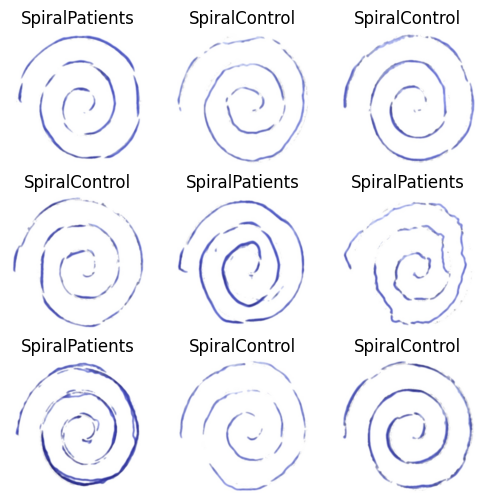

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1 import ImageGrid

fig = plt.figure(figsize=(6, 6))
# Crea un grid de 2 filas y 2 columnas
grid = ImageGrid(fig, 111, nrows_ncols=(3, 3), axes_pad=0.3)

for ax, im_path in zip(grid, df_data_test_fail_model_m['path']):
    true_label = im_path.split("/")[-2].split("_")[0]
    print(im_path)
    ax.imshow(mpimg.imread(im_path))
    ax.set_title(true_label)
    ax.axis('off') # Oculta los ejes

plt.savefig('grid_meander_ok.png', dpi=300)
plt.show()

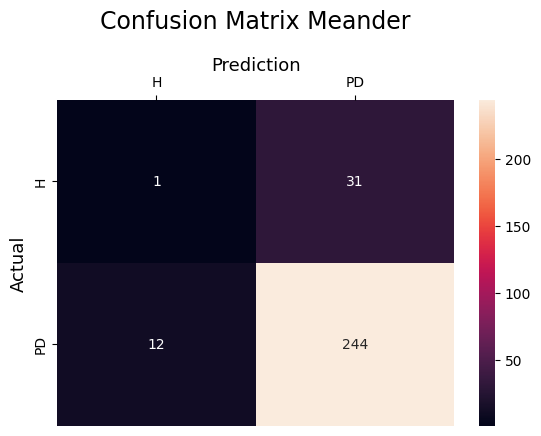

In [ ]:
cm = confusion_matrix(df_data_test_s_opos['true_label'],
                      df_data_test_s_opos['predicted_label'])

sns.heatmap(cm,
            annot=True,
            fmt='g',
            xticklabels=['H','PD'],
            yticklabels=['H','PD'])
plt.ylabel('Actual', fontsize=13)
plt.title('Confusion Matrix Meander', fontsize=17, pad=20)
plt.gca().xaxis.set_label_position('top')
plt.xlabel('Prediction', fontsize=13)
plt.gca().xaxis.tick_top()

plt.gca().figure.subplots_adjust(bottom=0.2)
plt.savefig('c_matrix_meander.png', dpi=300)
plt.show()

In [ ]:
print(classification_report(df_data_test_s_opos['true_label'], df_data_test_s_opos['predicted_label']))

              precision    recall  f1-score   support

           0       0.08      0.03      0.04        32
           1       0.89      0.95      0.92       256

    accuracy                           0.85       288
   macro avg       0.48      0.49      0.48       288
weighted avg       0.80      0.85      0.82       288



In [ ]:
t_type = 'Meander'
detect = DetectHandPD(t_type, 60, 15)
sub_t_type = 'Meander' if t_type == "Spiral" else "Spiral"
loss_data_s_opos, acc_train_s_opos, df_data_test_s_opos = detect.run('test', sub_t_type)

<Execute mode:test> <Type base:Meander> <Sub-Type:Spiral>
/content/drive/MyDrive/models/Spiral/Spiral_15.pth
/content/drive/MyDrive/MeanderControl_out_resize/
validating...


100%|██████████| 288/288 [00:05<00:00, 54.11it/s]

validation_loss: 0.52 validation_accuracy: 0.7743055555555556



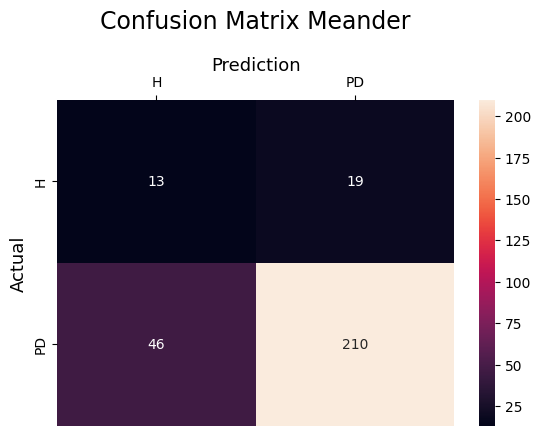

In [ ]:
cm = confusion_matrix(df_data_test_s_opos['true_label'],
                      df_data_test_s_opos['predicted_label'])

sns.heatmap(cm,
            annot=True,
            fmt='g',
            xticklabels=['H','PD'],
            yticklabels=['H','PD'])
plt.ylabel('Actual', fontsize=13)
plt.title('Confusion Matrix Meander', fontsize=17, pad=20)
plt.gca().xaxis.set_label_position('top')
plt.xlabel('Prediction', fontsize=13)
plt.gca().xaxis.tick_top()

plt.gca().figure.subplots_adjust(bottom=0.2)
plt.savefig('c_matrix_meander.png', dpi=300)
plt.show()

In [ ]:
print(classification_report(df_data_test_s_opos['true_label'], df_data_test_s_opos['predicted_label']))

              precision    recall  f1-score   support

           0       0.22      0.41      0.29        32
           1       0.92      0.82      0.87       256

    accuracy                           0.77       288
   macro avg       0.57      0.61      0.58       288
weighted avg       0.84      0.77      0.80       288



In [ ]:
df_data_test_fail_m = df_data_test_m_opos[df_data_test_m_opos['true_label'] != df_data_test_m_opos['predicted_label']]
df_data_test_ok_m = df_data_test_m_opos[df_data_test_m_opos['true_label'] == df_data_test_m_opos['predicted_label']]

/content/drive/MyDrive/MeanderPatients_out_resize/0149-6_TH.jpg
/content/drive/MyDrive/MeanderPatients_out_resize/0242-8_TH.jpg
/content/drive/MyDrive/MeanderPatients_out_resize/0143-5_TH.jpg
/content/drive/MyDrive/MeanderPatients_out_resize/0031-5_TH.jpg
/content/drive/MyDrive/MeanderPatients_out_resize/0004-5_TH.jpg
/content/drive/MyDrive/MeanderPatients_out_resize/0138-5_TH.jpg
/content/drive/MyDrive/MeanderPatients_out_resize/0240-5_TH.jpg
/content/drive/MyDrive/MeanderPatients_out_resize/0148-5_TH.jpg
/content/drive/MyDrive/MeanderPatients_out_resize/0037-5_TH.jpg


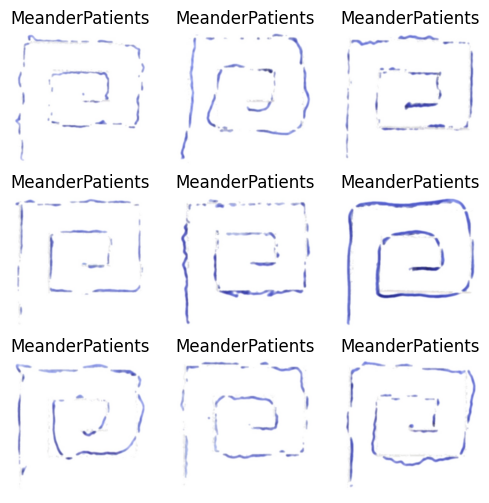

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1 import ImageGrid

fig = plt.figure(figsize=(6, 6))
# Crea un grid de 2 filas y 2 columnas
grid = ImageGrid(fig, 111, nrows_ncols=(3, 3), axes_pad=0.3)

for ax, im_path in zip(grid, df_data_test_ok_m['path']):
    true_label = im_path.split("/")[-2].split("_")[0]
    print(im_path)
    ax.imshow(mpimg.imread(im_path))
    ax.set_title(true_label)
    ax.axis('off') # Oculta los ejes

plt.savefig('grid_meander_ok.png', dpi=300)
plt.show()

/content/drive/MyDrive/MeanderControl_out_resize/0131-6_TH.jpg
/content/drive/MyDrive/MeanderControl_out_resize/0098-6_TH.jpg
/content/drive/MyDrive/MeanderPatients_out_resize/0207-5_TH.jpg
/content/drive/MyDrive/MeanderPatients_out_resize/0242-6_TH.jpg
/content/drive/MyDrive/MeanderPatients_out_resize/0044-8_TH.jpg
/content/drive/MyDrive/MeanderPatients_out_resize/0202-6_TH.jpg
/content/drive/MyDrive/MeanderPatients_out_resize/0234-8_TH.jpg
/content/drive/MyDrive/MeanderPatients_out_resize/0037-6_TH.jpg
/content/drive/MyDrive/MeanderControl_out_resize/0104-7_TH.jpg


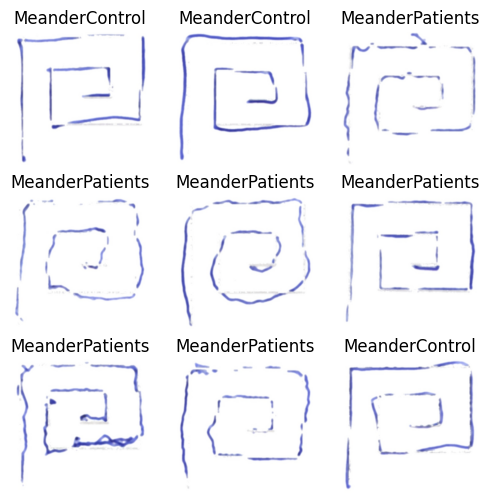

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1 import ImageGrid

fig = plt.figure(figsize=(6, 6))
# Crea un grid de 2 filas y 2 columnas
grid = ImageGrid(fig, 111, nrows_ncols=(3, 3), axes_pad=0.3)

for ax, im_path in zip(grid, df_data_test_fail_m['path']):
    true_label = im_path.split("/")[-2].split("_")[0]
    print(im_path)
    ax.imshow(mpimg.imread(im_path))
    ax.set_title(true_label)
    ax.axis('off') # Oculta los ejes

plt.savefig('grid_meander_ok.png', dpi=300)
plt.show()